# Homework 2: Nonlinear Programming and Evolutionary Algorithms

### In 2010, Prof. Quinn's husband, Alex Looi, conducted an experiment to model predator-prey dynamics in a chemostat (bioreactor) under different salinities. Each day, he measured the concentration of chlorella (a type of algae) and counted the number of rotifers (type of plankton that eats chlorella) in the chemostat. He modeled the chlorella and rotifer populations by the Fussman model of predator-prey dynamics (Fussman et al., 2000), represented by the following system of differential equations:
\begin{align}
    \frac{dN}{dt} = \delta (N_0 - N) - \frac{B_C N}{K_C + N} C \tag{1}\\
    \frac{dC}{dt} = \frac{B_C N}{K_C + N} C - \frac{B_R C}{K_R + C} \Big(\frac{R}{e}\Big) - \delta C \tag{2}\\
    \frac{dR}{dt} = \frac{B_R C}{K_R + C}R - (\delta + m)R \tag{3}
\end{align}
### where $C$, $R$, and $N$ are the quantities of chlorella, rotifers and nitrogen; $K_C$ and $K_R$ are the half-saturation constants of chlorella and rotifers; $B_C$ and $B_R$ are the growth rate of chlorella and rotifers; $e$ is the assimilation efficiency of the predator; $m$ is the mortality rate of the predator; and $\delta$ is the flow rate in the chemostat. He hypothesized that the half-saturation constant of the rotifers in this system, $K_R$, would be affected by salinity. Let's test his hypothesis! Attached is the data he collected, after being smoothed by exponential smoothing.

### Fussmann, G. F., Ellner, S. P., Shertzer, K. W., \& Hairston Jr, N. G. (2000). Crossing the Hopf bifurcation in a live predator-prey system. *Science*, *290*(5495), 1358-1360.

### 1. Compute the Hessians of the first and third equations and use the Hessians to explain why these two equations are not convex. (Don't worry about the second equation because it has three variables, making it more complicated!) Show your derivations by hand. (30 pts)
### **Hint: Recall the quotient rule**:
\begin{align}
        h(x) &= \frac{f(x)}{g(x)} \tag{4}\\
        h'(x) &= \frac{f'(x)g(x)-g'(x)f(x)}{[g(x)]^2} \tag{5}
\end{align}

$\color{red}{\text{Upload/transcribe your derivation here or upload as separate document.}}$

### 2. Using the Fussmann function below, simulate n=38 time steps of this model assuming the parameters and initial values provided in Table 1. Plot the Chlorella and Rotifer populations in solid black and red, respectively, on one plot with a shared ("twin") axis but different y axis. (10 pts)

Table 1: Example Inputs  

| Parameter | $K_C$ | $K_R$ | $B_C$ | $B_R$ | $e$  | $m$ | $\delta$ | $N_0$ | $C_0$ | $R_0$ |
| --------- | ----- | ---- | ----- | ----- | ---- | --- | -------- | ----- | ----- | ----- |
| Value     | 4.3   | 15.0 | 3.3   | 1.0   | 0.25 | 0.3 | 0.4      | 80    | 2.5     | 0.7  |

$\color{red}{\text{The code below is complete. It simulates a system of ordinary differential equations representing the Fussman model}}$

In [12]:
import scipy.integrate as integrate
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as ss
from scipy.optimize import differential_evolution, minimize

N0 = 80 # initial nitrogen mass
C0 = 2.5 # initial chlorella population
R0 = 0.7 # intiial rotifer population
delta = 0.4 # dilution rate

y0 = [N0, C0, R0] # initial state variables
time = np.arange(0, 38) # number of time steps

def Fussmann(y0, t, params):
    """
    The predator-prey code with Juveniles

    Parameters:
    _______________________________________________________
    betaC: params[0]  # Offspring production: Chlorella
    Kc:    params[1]  # Half Saturation constant of Chlorella
    e:     params[2]  # Assimilation efficiency of rotifers
    m:     params[3]  # Death rate of Rotifers
    betaR: params[4]  # Offspring production of Rotifers
    Kr:    params[5]  # Half saturation constant for R

    Populations:
    _______________________________________________________
    dN: Concentration of Nitrogen
    dC: Concentration of Chlorella
    dR: Concentration of Rotifers
    """
    ## Parameters
    # Whole system parameters
    #d = parms[0]

    # Chlorella parameters
    K_C = params[0] # Half Saturation constant for Chlorella
    K_R = params[1] # Half saturation constant for Rotifers
    B_C = params[2] # Growth rate of Chlorella
    B_R = params[3] # Growth rate of Rotifers
    e = params[4] # Assimilation rate of Rotifers
    m = params[5] # Death rate of Rotifers

    ##initial conditions
    N = y0[0]
    C = y0[1]
    R = y0[2]

    ##Differential equations
    dN = delta*(N0 - N) - (B_C*N)/(K_C + N)*C # rate of change in nitrogen
    dC = (B_C*N)/(K_C + N)*C - ((B_R*C) / (K_R + C)*R/e) - delta*C # rate of change in chlorella population
    dR = (B_R*C)/(K_R + C)*R - (delta + m) * R # rate of change of rotifer population

    return [dN, dC, dR]

$\color{red}{\text{Run simulation with default parameters and plot resulting time series below.}}$

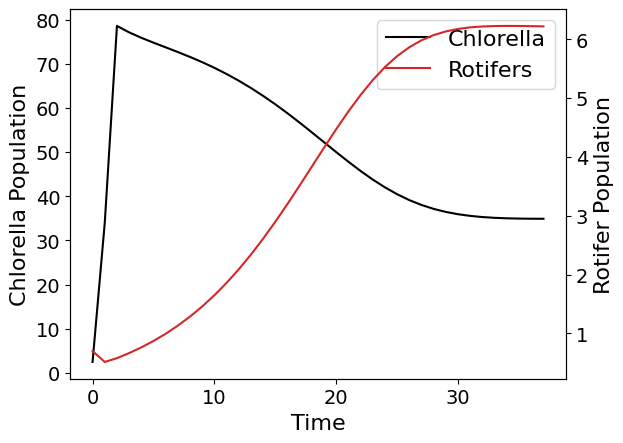

In [13]:
params = [4.3, 15.0, 3.3, 1.0, 0.25, 0.3]

soln = integrate.odeint(Fussmann, y0, time, args=(params,))

fig, ax = plt.subplots()
ln1 = ax.plot(soln[:,1],label="Chlorella",color="black")
ax.tick_params(labelsize=14)
ax.set_ylabel("Chlorella Population",fontsize=16)
ax.set_xlabel("Time",fontsize=16)
ax2 = ax.twinx()
ln2 = ax2.plot(soln[:,2],label="Rotifers",color="tab:red")
ax2.tick_params(labelsize=14)
ax2.set_ylabel("Rotifer Population",fontsize=16)
lns = ln1 + ln2
labs = [l.get_label() for l in lns]
ax.legend(lns, labs, fontsize=16, loc="upper right")
fig.show()

# run simulation and make plot here


### b. Now let's use this model to fit Alex's data, which is a time series of 38 time steps. The values of N0, C0, R0 and $\delta$ were measured in the lab and are the same as those listed in Table 1. The other 6 parameters need to be estimated from the data. Generate a Latin hypercube of 50 samples of these 6 parameters over their bounds, provided in Table 2 (set the seed to make it reproducible). Use these to initialize the population of a search with Differential Evolution for the set of parameters that maximizes the average NSE of simulated and observed chlorella and rotifer populations under each salinity (again, set the seed to make it reproducible). Report the average NSE and parameter estimates of each fit. Note that the Algae columns correspond to Chlorella populations. Hint: You will need to update your Fussmann function to take observed C and R values as an argument and return the negative of the average NSE when those arguments are passed. (20 pts)

Table 2: Parameter Ranges  

| Parameter   | Lower Bound | Upper Bound |
| ----------- | ----------- | ----------- |
| $ K_C $     | 1.0         | 25.0        |
| $ K_R $     | 1.0         | 50.0        |
| $ B_C $     | 1.0         | 10.0        |
| $ B_R $     | 0.1         | 10.0        |
| $ e $       | 0.01        | 0.50        |
| $ m $       | 0.0         | 0.9         |

$\color{red}{\text{The code below is complete. It reads in the data and then organizes it into a dictionary, dic_dfs,}}$  
$\color{red}{\text{where each salinity has a data frame of rotifer and chlorella populations associated with it.}}$

In [14]:
# read in experimental data
from google.colab import drive
import pandas as pd

drive.mount('/content/drive')
data = pd.read_csv("drive/MyDrive/Colab Notebooks/CE4110_6250/ExpData.csv")

# create dictionaries with the key being the salinity and the value being the associated observed dataset
salinities = []

for colname in data.columns:
    salinity = colname.split(".")[-1]
    if salinity not in salinities:
        salinities.append(salinity)

dic_dfs = {}
for salinity in salinities:
    for colname in data.columns:
        if colname.split(".")[-1] == salinity:
            if colname.split(".")[0].split(" ")[-1] == "Rotifers":
                S_R = data[colname]
                S_R.name = "R"
            if colname.split(".")[0].split(" ")[-1] == "Algae":
                S_C = data[colname]
                S_C.name = "C"
    dic_dfs[salinity] = pd.concat([S_R,S_C], axis = 1)
dic_dfs

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


{'3':            R           C
 0   1.601544    2.279321
 1   0.918466    2.682872
 2   0.523395    3.830515
 3   0.444546    7.853645
 4   0.693212   17.042953
 5   1.271072   32.081756
 6   2.398660   50.206668
 7   4.109004   64.227486
 8   6.487622   56.082956
 9   8.705628   30.198051
 10  9.412891    8.774474
 11  8.469051   -0.146444
 12  6.170896   -1.311569
 13  3.725722   -0.011590
 14  2.064962    1.562006
 15  1.245003    3.447101
 16  1.038647    6.746106
 17  1.191662   13.118507
 18  1.584543   23.154539
 19  2.030264   36.360770
 20  2.536535   52.901554
 21  3.228269   72.368672
 22  3.600482   90.259022
 23  3.446207   99.210725
 24  3.179634  101.927336
 25  3.210101  103.809861
 26  3.471853  105.808330
 27  3.559012  105.468220
 28  3.530607  100.748633
 29  3.647057   91.414280
 30  4.197914   78.210027
 31  5.090517   61.235098
 32  6.029186   46.965549
 33  6.885814   34.821909
 34  7.701714   20.593401
 35  7.627521    4.516909
 36  6.157616    2.279321
 37  4.

$\color{red}{\text{Complete the function below to calculate the objective function: average NSE of chlorella and rotifer populations. Negate to minimize.}}$

In [15]:
N0 = 80 # initial nitrogen mass
C0 = 2.5 # initial chlorella population
R0 = 0.7 # intiial rotifer population
delta = 0.4 # dilution rate

def ObjFunc(params, y0, t, data):

    """
    The Fitness Function: the average of Rotifer NSE and Chlorella NSE.
    """
    # compute objective function


    soln = integrate.odeint(Fussmann, y0, time, args=(params,))

    NSE_R = 1 - np.sum((soln[:,2]-data["R"])**2)/np.sum((data["R"] - np.mean(data["R"]))**2)
    NSE_C = 1 - np.sum((soln[:,1]-data["C"])**2)/np.sum((data["C"] - np.mean(data["C"]))**2)

    ObjFunc = -(NSE_R + NSE_C)/2
    return ObjFunc


$\color{red}{\text{Complete the code below to calibrate with DE}}$

In [18]:
# specify parameter bounds

#Bounds go in order: [K_C, K_R, B_C, B_R, e, m]
l_bounds = np.array([1, 1, 1, 0.1, 0.01, 0.0])
u_bounds = np.array([25, 50, 10, 10, 0.5, 0.9])
bounds = [(1, 25), (1, 50), (1, 10), (0.1, 10), (0.01, 0.5), (0.0, 0.9)]


# generate initial population of 50 from Latin hypercube sample with seed=1
sampler = ss.qmc.LatinHypercube(d=6,seed=1)
sample = sampler.random(n=50)
x0 = ss.qmc.scale(sample, l_bounds, u_bounds)
x0

# initialize data frame of 0s that will later store results
DE_results = pd.DataFrame(columns=["K_C","K_R","B_C","B_R","e","m","NSE"],index=salinities,data=0.0)

# loop through salinities and optimize parameters with DE
for salinity in dic_dfs.keys():
    df_obs = dic_dfs[salinity] # data of chlorella and rotifer populations at this salinity
    # use DE to optimize ObjFunc
    result = differential_evolution(ObjFunc, bounds=bounds, init=x0, seed=1, maxiter=1000, args=(y0, time, df_obs))

    # fill data frame with parameter values and objective value (finish code below)
    DE_results.iloc[np.where(DE_results.index == salinity),0:len(bounds)] = result.x # parameter values
    DE_results["NSE"].iloc[np.where(DE_results.index == salinity)] = -result.fun # objective value



DE_results

/tmp/ipykernel_4994/2693198318.py:14: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with full_output = 1 to get quantitative information.
  soln = integrate.odeint(Fussmann, y0, time, args=(params,))
/tmp/ipykernel_4994/922017317.py:26: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas

,K_C,K_R,B_C,B_R,e,m,NSE
3,25.000000,50.000000,1.943269,3.493998,0.451210,0.900000,-0.174693
16,11.078770,5.321053,1.754659,1.475375,0.118861,0.058645,-0.636007
35,15.665345,8.265667,2.016885,1.209901,0.251937,0.266443,-0.680559
45,1.132502,4.477189,1.000000,1.507670,0.500000,0.871635,-0.697871


### c. Generate another Latin hypercube with 10 samples to serve as initial estimates to scipy.optimize.minimize with the default solver (BFGS). Again, set the seed to 1 to make it reproducible. Use this solver to find a set of parameters that maximizes the average NSE of simulated and observed chlorella and rotifer populations under each salinity. Report the NSEs and parameter estimates in a pandas dataframe in which each row corresponds to a salinity and each column corresponds to NSE or a parameter. (20 pts)

$\color{red}{\text{Complete the code below to calibrate with BFGS}}$

In [23]:
# generate initial population of 50 from Latin hypercube sample with seed=1
sampler = ss.qmc.LatinHypercube(d=6,seed=1)
sample = sampler.random(n=10)
x0 = ss.qmc.scale(sample, l_bounds, u_bounds)
x0

# initialize data frame of 0s that will later store results
BFGS_results = pd.DataFrame(columns=["K_C","K_R","B_C","B_R","e","m","NSE"],index=salinities,data=0.0)
BFGS_x_best = np.zeros([7])

# loop through salinities and optimize parameters with BFGS
for salinity in dic_dfs.keys():
    df_obs = dic_dfs[salinity] # data of chlorella and rotifer populations at this salinity
    bestObj = np.inf # initialize the best objective value so far for this salinity at infinity
    # loop through initial starting points and update bestObj value and corresponding result if it improved
    for i in range(10):
      BFGSresult = minimize(ObjFunc, x0[i,:], bounds=bounds, args=(y0, time, df_obs))
      if BFGSresult.fun < bestObj:
         Best_x_results = BFGSresult.x
         bestObj = BFGSresult.fun



    # fill data frame with parameter values and objective value (finish code below)
    BFGS_results.iloc[np.where(BFGS_results.index == salinity),0:len(bounds)] = Best_x_results # parameter values
    BFGS_results["NSE"].iloc[np.where(BFGS_results.index == salinity)] = -bestObj # objective value

BFGSresult

/tmp/ipykernel_4994/2693198318.py:14: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with full_output = 1 to get quantitative information.
  soln = integrate.odeint(Fussmann, y0, time, args=(params,))
/tmp/ipykernel_4994/4262376611.py:26: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/panda

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 0.4648447882028357
        x: [ 1.812e+00  3.492e+00  1.000e+00  1.000e-01  4.943e-01
             0.000e+00]
      nit: 3
      jac: [ 4.123e-01  1.426e-01  2.382e-01  1.902e-01  2.224e-01
             1.001e-01]
     nfev: 154
     njev: 22
 hess_inv: <6x6 LbfgsInvHessProduct with dtype=float64>

In [24]:
BFGS_results

,K_C,K_R,B_C,B_R,e,m,NSE
3,3.114726,34.773253,2.717830,2.625378,0.319661,0.900000,0.099562
16,13.966303,13.079504,3.470386,6.557474,0.130280,0.117709,0.154019
35,24.997756,1.003789,1.063910,0.551560,0.291210,0.018581,0.412233
45,1.000000,2.631843,1.000000,1.484541,0.475300,0.900000,0.699703


### $\color{red}{\text{Which algorithm achieves better NSE values, and what does that suggest?}}$

### d. Make a 4x2 plot of the time series of observed and modeled chlorella and rotifer populations. Each row will represent a different salinity, the left column will show the gradient-based method results, and the right column will show the differential evolution results. Use a solid black line to represent the observed chlorella population and a dashed black line to represent the modeled chlorella population (hint: pass linestyle="dashed" to ax.plot). On the opposite y axis, but a shared ("twin") x axis, use a solid red line to represent the observed rotifer population and a dashed red line to represent the modeled rotifer population. (20 pts)

$\color{red}{\text{Fill in the code below to make your plot.}}$

In [ ]:
fig, ax = plt.subplots(4,2)
fig.set_size_inches([10,8])

for salinity in dic_dfs.keys():
    df_obs = dic_dfs[salinity] # observed population data for this salinity
    for j in range(2):
        if j == 0:
            # get simulated chlorella and rotifer populations from best DE solution for this salinity

        else:
            # get simulated chlorella and rotifer populations from best BFGS solution for this salinity


        # plot simulated and observed populations

        if i == 0:
            if j == 0:
                ax[i,j].set_title("DE Calibration",fontsize=16)
            else:
                ax[i,j].set_title("BFGS Calibration", fontsize=16)

# add a legend to the figure


### $\color{red}{\text{Which algorithm's estimated parameters produce dynamics closer to the observations?}}$